# Avance 3 - Aprendizaje no supervisado

### Clustering y Reducción de Dimensionalidad

Esta parte implementa técnicas de aprendizaje no supervisado para segmentación
de clientes y visualización de patrones en los datos.

## Descripción del dataset

* RowNumber: Índice de la fila.
* CustomerId: Identificador único para cada cliente.
* Surname: Apellido del cliente (puede no ser útil para el análisis).
* CreditScore: Puntuación crediticia del cliente [300 : 850].
* Geography: País del cliente (ej. Francia, España).
* Gender: Género del cliente (ej. Masculino, Femenino).
* Age: Edad del cliente.
* Tenure: Número de años que el cliente ha estado con el banco.
* Balance: Saldo de cuenta del cliente.
* NumOfProducts: Número de productos que ha comprado el cliente.
* HasCrCard: Si el cliente tiene tarjeta de crédito (1 = Sí, 0 = No).
* IsActiveMember: Si el cliente es un miembro activo (1 = Sí, 0 = No).
* EstimatedSalary: Salario anual estimado del cliente.
* Exited: Si el cliente dejó el banco (1 = Sí, 0 = No) – esta es la variable objetivo.

## 0. Vista previa de los datos

In [13]:
# Importar todas las librerías necesarias
import numpy as np
import pandas as pd
import seaborn as sns
sns.set(style="darkgrid", font_scale=1.2)
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import pairwise_distances, silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.neighbors import NearestNeighbors
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

Metricas
- *calinski*: que tan homogeneos es cada clauster por dentro (mientras mas alto mejor)
- *davies_bouldin*: que tan homogeneos son todos los clusters en conjunto entre si (mientras mas bajo mejor)

In [14]:
# Leer y preparar datos (mismo procesamiento de partes anteriores)
df = pd.read_csv('Churn_Modelling.csv')

# Eliminar columnas innecesarias
df_processed = df.drop(columns=['RowNumber', 'CustomerId', 'Surname'])

## 1. Feature Engineering

In [15]:
# Feature Engineering (mismo que partes anteriores)
df_processed['AgeGroup'] = pd.cut(df_processed['Age'],
                                bins=[0, 30, 50, 100],
                                labels=['Joven', 'Adulto', 'Mayor'])

df_processed['BalanceGroup'] = pd.cut(df_processed['Balance'],
                                    bins=[0, 50000, 150000, float('inf')],
                                    labels=['Bajo', 'Medio', 'Alto'],
                                    include_lowest=True)

df_processed['ProductsPerTenure'] = df_processed['NumOfProducts'] / (df_processed['Tenure'] + 1)
df_processed['ActiveWithCard'] = df_processed['IsActiveMember'] * df_processed['HasCrCard']

Se añaden las siguientes features: 
- *AgeGroup* -> 'Joven', 'Adulto', 'Mayor' 
Permiten diferenciar bien las edades, segun las etapas de vida de cada persona

- *BalanceGroup* -> 'Bajo', 'Medio', 'Alto' 
Division en 3 grupos por saldo de la cuenta del cliente en el banco para diferenciar su distinto comportamiento. Ej: No se va a pretender que un cliente con bajo saldo tenga muchos productos

- *ProductsPerTenure* -> NumOfProducts/(Tenure + 1) 
Que tanto consumo realiza los clientes segun el tiempo que hayan sido parte del banco

- *ActiveWithCard* -> IsActiveMember * HasCrCard
Aquellos que estan en el banco de manera activa

## 2. Split Train-Test + Preprocesamiento

#### Split 80/20

In [16]:
# Definir features y target
X = df_processed.drop('Exited', axis=1)
y = df_processed['Exited']

# División train-test (mismo que partes anteriores)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

OneHotEncoder -> categoricals 


StandardScaler -> numerical

In [17]:
# Identificar variables
categorical_cols = ['Geography', 'Gender', 'AgeGroup', 'BalanceGroup']
numerical_cols = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'EstimatedSalary', 'ProductsPerTenure']
binary_cols = ['HasCrCard', 'IsActiveMember', 'ActiveWithCard']

# Preprocesamiento (mismo que partes anteriores)
ohe = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='infrequent_if_exist')
X_train_categorical = ohe.fit_transform(X_train[categorical_cols])
X_test_categorical = ohe.transform(X_test[categorical_cols])

feature_names = ohe.get_feature_names_out(categorical_cols)
X_train_cat_df = pd.DataFrame(X_train_categorical, columns=feature_names, index=X_train.index)
X_test_cat_df = pd.DataFrame(X_test_categorical, columns=feature_names, index=X_test.index)

scaler = StandardScaler()
X_train_numerical = scaler.fit_transform(X_train[numerical_cols])
X_test_numerical = scaler.transform(X_test[numerical_cols])
X_train_num_df = pd.DataFrame(X_train_numerical, columns=numerical_cols, index=X_train.index)
X_test_num_df = pd.DataFrame(X_test_numerical, columns=numerical_cols, index=X_test.index)

X_train_binary = X_train[binary_cols]
X_test_binary = X_test[binary_cols]

# Combinar datos procesados
X_train_processed = pd.concat([X_train_num_df, X_train_cat_df, X_train_binary], axis=1)
X_test_processed = pd.concat([X_test_num_df, X_test_cat_df, X_test_binary], axis=1)

print(f"Datos preparados - Train: {X_train_processed.shape}, Test: {X_test_processed.shape}")

Datos preparados - Train: (8000, 17), Test: (2000, 17)


#### Preparacion de datos para clustering

In [18]:
# Preparacion de datos para clustering
# Uso X_train ya que no estoy utilizando la columna del target 
X_clustering = X_train_processed.copy()
X_clustering

,CreditScore,Age,Tenure,Balance,NumOfProducts,EstimatedSalary,ProductsPerTenure,Geography_Germany,Geography_Spain,Gender_Male,AgeGroup_Joven,AgeGroup_Mayor,BalanceGroup_Bajo,BalanceGroup_Medio,HasCrCard,IsActiveMember,ActiveWithCard
2151,1.058568,1.715086,0.684723,-1.226059,-0.910256,1.042084,-0.719828,0.0,0.0,1.0,0.0,1.0,1.0,0.0,1,0,0
8392,0.913626,-0.659935,-0.696202,0.413288,-0.910256,-0.623556,-0.346241,1.0,0.0,1.0,0.0,0.0,0.0,1.0,1,0,0
5006,1.079274,-0.184931,-1.731895,0.601687,0.808830,0.308128,4.883987,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1,1,1
4117,-0.929207,-0.184931,-0.005739,-1.226059,0.808830,-0.290199,-0.097182,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1,0,0
7182,0.427035,0.955079,0.339492,0.548318,0.808830,0.135042,-0.239501,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4555,0.385623,-0.374933,0.339492,-1.226059,-0.910256,-1.294966,-0.666459,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1,0,0
4644,0.634095,3.330101,-0.005739,-1.226059,0.808830,0.901685,-0.097182,0.0,1.0,1.0,0.0,1.0,1.0,0.0,0,0,0
8942,0.168210,-0.184931,1.375185,-0.073747,0.808830,-0.558088,-0.495676,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1,1,1
2935,0.375270,-0.374933,1.029954,0.394991,0.808830,-1.351500,-0.429260,0.0,1.0,1.0,0.0,0.0,0.0,1.0,1,0,0


## 3. PCA 


=== REDUCCIÓN DE DIMENSIONALIDAD ===
Aplicando PCA...
Componentes para 90% varianza: 9
Componentes para 95% varianza: 11


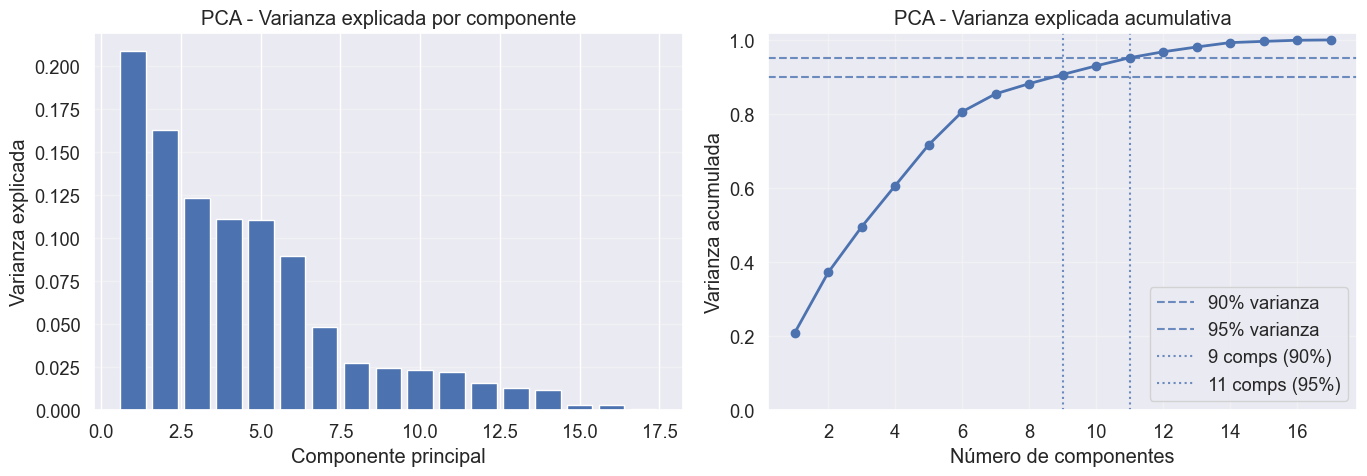

In [19]:
print("\n=== REDUCCIÓN DE DIMENSIONALIDAD ===")

# PCA
print("Aplicando PCA...")

# Varianza explicada (PCA con todos los componentes posibles)
pca_full = PCA(random_state=42)
pca_full.fit(X_clustering)

explained_var = pca_full.explained_variance_ratio_
cum_explained_var = np.cumsum(explained_var)

# Mostramos cuántos componentes explican el 90% y 95%
n_90 = int(np.argmax(cum_explained_var >= 0.90) + 1)
n_95 = int(np.argmax(cum_explained_var >= 0.95) + 1)
print(f"Componentes para 90% varianza: {n_90}")
print(f"Componentes para 95% varianza: {n_95}")

# GRÁFICOS 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# A) Varianza explicada por componente
axes[0].bar(range(1, len(explained_var) + 1), explained_var)
axes[0].set_title("PCA - Varianza explicada por componente")
axes[0].set_xlabel("Componente principal")
axes[0].set_ylabel("Varianza explicada")
axes[0].grid(True, axis="y", alpha=0.3)

# B) Varianza explicada acumulativa
axes[1].plot(range(1, len(cum_explained_var) + 1), cum_explained_var, marker="o", linewidth=2)
axes[1].axhline(0.90, linestyle="--", alpha=0.8, label="90% varianza")
axes[1].axhline(0.95, linestyle="--", alpha=0.8, label="95% varianza")
axes[1].axvline(n_90, linestyle=":", alpha=0.8, label=f"{n_90} comps (90%)")
axes[1].axvline(n_95, linestyle=":", alpha=0.8, label=f"{n_95} comps (95%)")

axes[1].set_title("PCA - Varianza explicada acumulativa")
axes[1].set_xlabel("Número de componentes")
axes[1].set_ylabel("Varianza acumulada")
axes[1].set_ylim(0, 1.02)
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

PCA se encarga de explicar en 2 componentes las similitudes en un grafico de manera visual. Este grafico quiere decir que para conseguir un 90% de varianza se necesitan 9 componentes. Se realizo con 2 componentes y se obtubo una varianza de ~40% aproximadamente lo cual no representa una gran catidad de datos.

## 4. KMeans

### 4.1 Calculo de metricas para K entre 2 y 10

**Inertia** (metodo del codo, K optimo): mide la suma de las distancias de cada punto a su centroide.
* 🔽 Más baja = mejor (clusters más compactos)
* 🔼 Más alta = peor (clusters muy desparramados)

**silhouette_scores** (mas alto mejor): que tan bien encaja cada cliente (entre -1 y 1). 0,5 ya es muy buen resultado
* 🟢 ¿Está cerca de los de su mismo grupo?
* 🔴 ¿Está lejos de los de otros grupos?

**calinski_harabasz_scores** (mas alto mejor): Qué tan compactos son los clusters por dentro
* Qué tan compactos son los clusters por dentro
* Qué tan separados están entre sí

**Davies–Bouldin Score** (más bajo mejor): Mide qué tan “confundibles” son los clusters entre sí (< 0.5 es muy bueno).
* 🟢 Estan bien separados?
* 🔴 Se superponen entre si?



In [20]:
#Buscamos el numero optimo de clusters para K-Means

#Metricas calculadas para K de 2 a 10 
inertias = []
silhouette_scores = [] 
calinski_harabasz_scores = []
davies_bouldin_scores = []
k_range = range(2, 11)

print("Calculando metricas para K de 2 a 10...")

for k in k_range:
    # definimos el modelo KMeans
    kmeans = KMeans(n_clusters=k, random_state=42)

    # hacemos el fit y predecimos los labels
    labels = kmeans.fit_predict(X_clustering)
    
    # almacenamos las métricas
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_clustering, labels))
    calinski_harabasz_scores.append(calinski_harabasz_score(X_clustering, labels))
    davies_bouldin_scores.append(davies_bouldin_score(X_clustering, labels))

Calculando metricas para K de 2 a 10...


### 3.2 Graficos de metricas

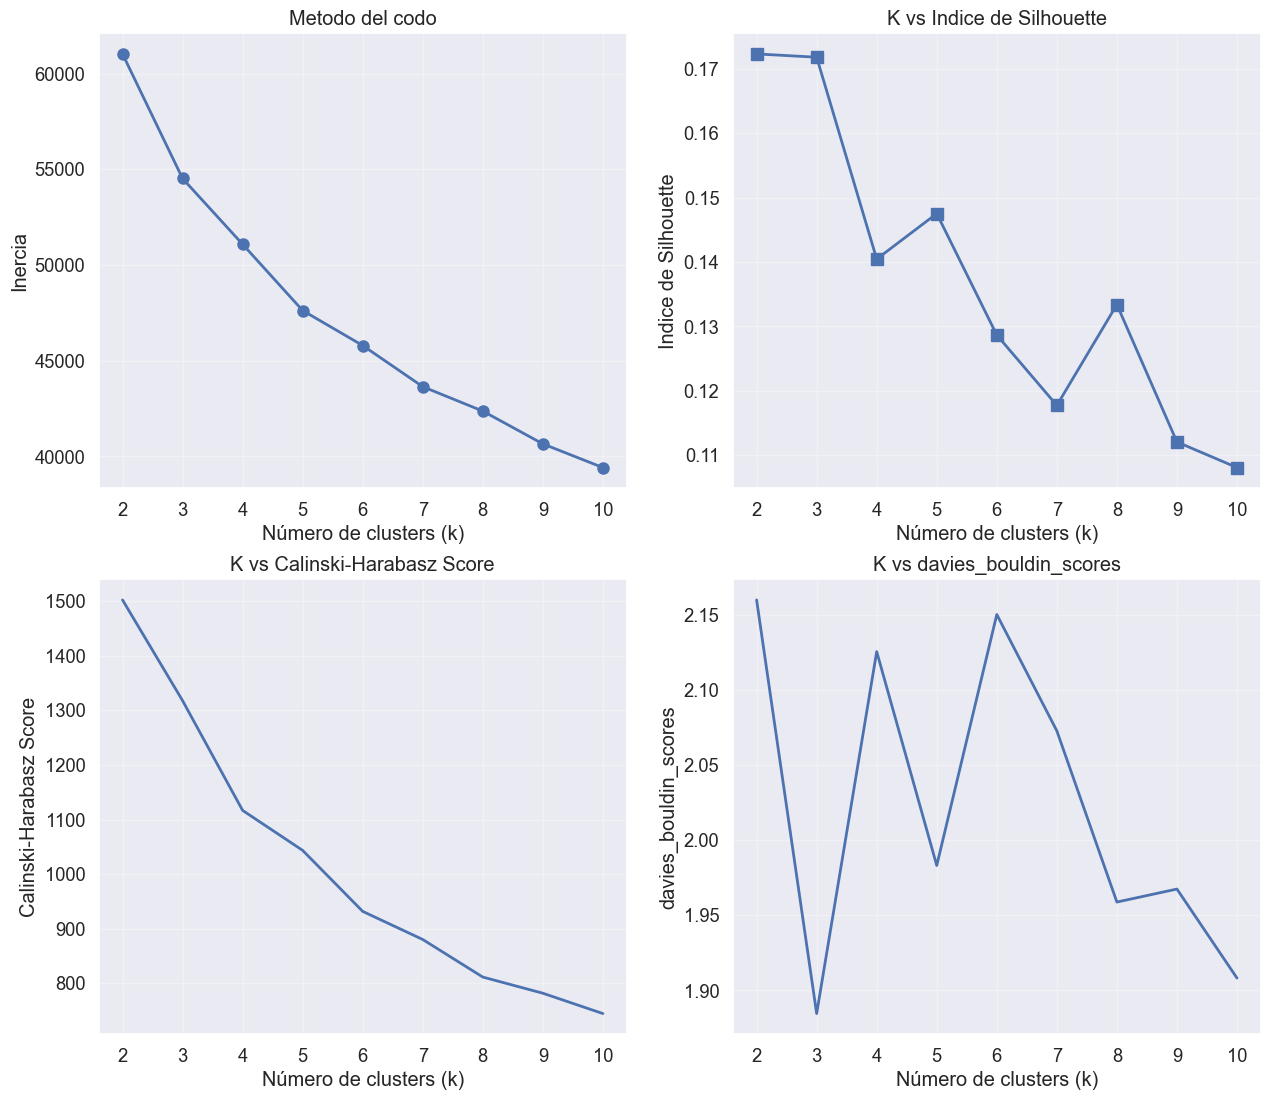

In [21]:
# Visualizar métricas de evaluación
fig, axes = plt.subplots(2, 2, figsize=(15, 13))

# Método del codo

# Inertias vs K
axes[0,0].plot(k_range, inertias, marker='o', linewidth=2, markersize=8)
axes[0,0].set_xlabel('Número de clusters (k)')
axes[0,0].set_ylabel('Inercia')
axes[0,0].set_title('Metodo del codo')
axes[0,0].grid(True, alpha=0.3)

# Silhouette Score vs K (mayor es mejor)
axes[0,1].plot(k_range, silhouette_scores, marker='s', linewidth=2, markersize=8)
axes[0,1].set_xlabel('Número de clusters (k)')
axes[0,1].set_ylabel('Indice de Silhouette')
axes[0,1].set_title('K vs Indice de Silhouette')
axes[0,1].grid(True, alpha=0.3)

# Calinski-Harabasz Score vs K(mayor es mejor)
axes[1,0].plot(k_range, calinski_harabasz_scores, linewidth=2, markersize=8)
axes[1,0].set_xlabel('Número de clusters (k)')
axes[1,0].set_ylabel('Calinski-Harabasz Score')
axes[1,0].set_title('K vs Calinski-Harabasz Score')
axes[1,0].grid(True, alpha=0.3)

# Davies-Bouldin Score vs K (menor es mejor)
axes[1,1].plot(k_range, davies_bouldin_scores, linewidth=2, markersize=8)
axes[1,1].set_xlabel('Número de clusters (k)')
axes[1,1].set_ylabel('davies_bouldin_scores')
axes[1,1].set_title('K vs davies_bouldin_scores')
axes[1,1].grid(True, alpha=0.3)



Para el grafico de **inercia** (metodo del codo): en el grafico no se visualiza un codo bien definido. Podria suponerse que esta ubicado en *k=3*.

Para el grafico de **calinski** (que tan compactos son los clusters por dentro): teniendo en cuenta que el resultado mas alto es el mejor, se podria elegir en *k=2* que esta en los 1500 puntos.

Para el grafico de **silhouette** (que tan bien encaja cada cliente en su grupo): las opciones de *k=2 o k=3* son similares ~0.17 aun que no son muy buenas en general ya que se considere razonable que el valor se encuentre dentro 0.5 y 0.25.

Para el grafico de **davies bouldin** (que tan confundible son los clusters, mas bajo mejor): una muy buena opcion seria seleccionar *k=3* ya que es el punto mas bajo del grafico ~1.90.

### 4.3 Toma de desición

En base a los gráficos, hemos decidido tomar como "k" óptimo a 2, es decir, vamos a agrupar a los clientes del banco en 2 clusters.

In [22]:
# vamos a calcular cúantos clientes hay en cada cluster 

# definimos el modelo KMeans con k=3 (óptimo según gráficos)
optimal_k = 3
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init='auto')
kmeans_labels = kmeans_final.fit_predict(X_clustering)

# agrupar etiquetas al dataset
X_clustering['Cluster'] = kmeans_labels

cluster_data = X_train.copy() # dataset original sin escalar 

cluster_data['Cluster'] = kmeans_labels
cluster_data['Exited'] = y_train # target 

# distribución de clientes en cada cluster
cluster_counts = pd.Series(kmeans_labels).value_counts().sort_index()

cluster_percentages = (cluster_counts / cluster_counts.sum() * 100).round(2)
cluster_summary = pd.DataFrame({
    "Clientes": cluster_counts,
    "Porcentaje (%)": cluster_percentages
})

print("\nDistribución de clientes por cluster:")
print(cluster_summary)



Distribución de clientes por cluster:
   Clientes  Porcentaje (%)
0      2643           33.04
1      4357           54.46
2      1000           12.50


Se puede ver que el cluster con mayor cantidad de clientes es 2 con 4357 clientes siendo un 54.46% del total de clientes. En segundo lugar se encuentra el cluster 0 con un 33% de clientes representando a 2643 clientes. Por ultimo esta el cluster 1 con la menor cantidad de clientes representando el 12% de ellos (1000 clientes).

### 4.4 T-sne + PCA 2D en k-means

Con **PCA** el principal objetivo es reducir las dimesiones a 2 para visualizarlo mejor de una manera grafica. Aprende cuáles son las 2 direcciones más importantes (PC1 y PC2) y luego proyecta todos los puntos a esas 2 direcciones. Se muestra tambien la varianza, cuanta info del dataset representa una determinada columna.

Con **T-sne** preservar las *similitudes* entre pares de puntos de datos en un espacio de dimensiones inferiores. Tiene el parametro perplexity para saber cuántos vecinos considera, en este caso decido tomar 30 vecinos.

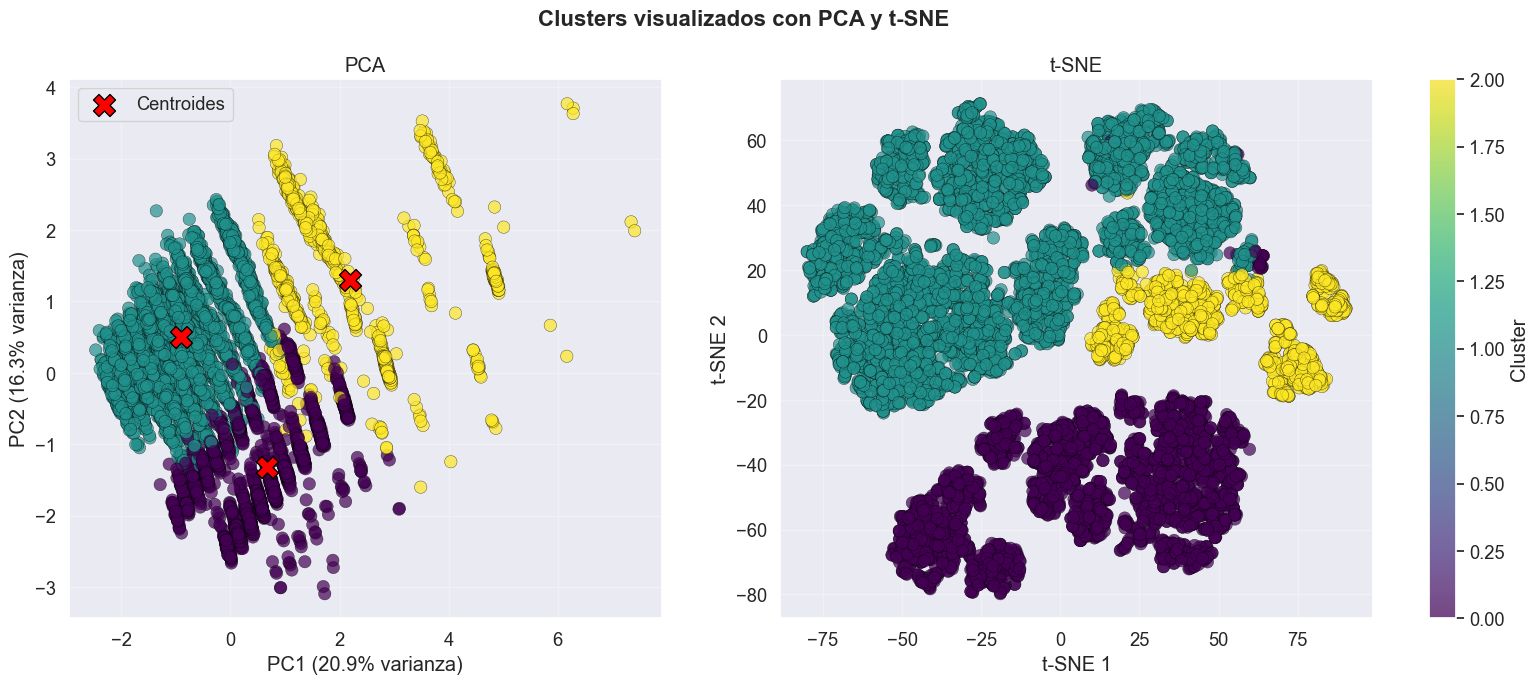

In [23]:
# PCA: resumo los datos en 2 columnas 
pca_vis = PCA(n_components=2, random_state=42)

# se elimina el target ya que no es necesario
# errors="ignore" -> evita errores si la columna no existe
X_pca = pca_vis.fit_transform(X_clustering.drop(columns=["Cluster"], errors="ignore")) 

#Obtengo los centroides para dibujarlos
centroids_original = kmeans_final.cluster_centers_
centroids_pca = pca_vis.transform(centroids_original)

#Varianza de cada columna
var_pc1 = pca_vis.explained_variance_ratio_[0] * 100
var_pc2 = pca_vis.explained_variance_ratio_[1] * 100

#============================

# t-SNE 

#Asignamos variables para t-SNE
tsne_idx = X_clustering.index.values
X_tsne_input = X_clustering
labels_tsne = kmeans_labels

#Definimos perplexity
perplexity = 30

#Creamos tsne y transformamos el X_tsne
tsne = TSNE(
    n_components=2,
    random_state=42,
    perplexity=perplexity,
    learning_rate="auto",
)

X_tsne = tsne.fit_transform(X_tsne_input)


# Plot unificado
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle("Clusters visualizados con PCA y t-SNE", fontsize=16, fontweight="bold")

# PCA subplot
sc1 = axes[0].scatter(
    X_pca[:, 0], X_pca[:, 1],
    c=kmeans_labels,
    cmap="viridis",
    s=80,
    alpha=0.7,
    edgecolors="black",
    linewidths=0.3
)

axes[0].scatter(
    centroids_pca[:, 0], centroids_pca[:, 1],
    c="red",
    s=250,
    marker="X",
    edgecolors="black",
    label="Centroides"
)

axes[0].set_title("PCA")
axes[0].set_xlabel(f"PC1 ({var_pc1:.1f}% varianza)")
axes[0].set_ylabel(f"PC2 ({var_pc2:.1f}% varianza)")
axes[0].grid(True, alpha=0.3)
axes[0].legend()

# t-SNE subplot
sc2 = axes[1].scatter(
    X_tsne[:, 0], X_tsne[:, 1],
    c=labels_tsne,
    cmap="viridis",
    s=80,
    alpha=0.7,
    edgecolors="black",
    linewidths=0.3
)

axes[1].set_title("t-SNE")
axes[1].set_xlabel("t-SNE 1")
axes[1].set_ylabel("t-SNE 2")
axes[1].grid(True, alpha=0.3)

# Colorbar compartida
cbar = fig.colorbar(sc1, ax=axes, orientation="vertical", fraction=0.025, pad=0.04)
cbar.set_label("Cluster")

plt.show()

**PCA**: Se visualiza la division de los 3 clusters, existiendo asi algunos solapamientos. Debemos tener en cuenta, que no se estan distinguiendo los outliers.

**T-sne**: La estructura de 3 clusters bien marcados, no parece una segmentación forzada.

**Conclusion eleccion K=3**: se considera una buena eleccion. En t-SNE se ven exactamente 3 macrogrupos naturales y no hay evidencia visual de que falte un cluster o que haya uno partido en dos.

### 4.5 Clientes por Cluster de K-Means

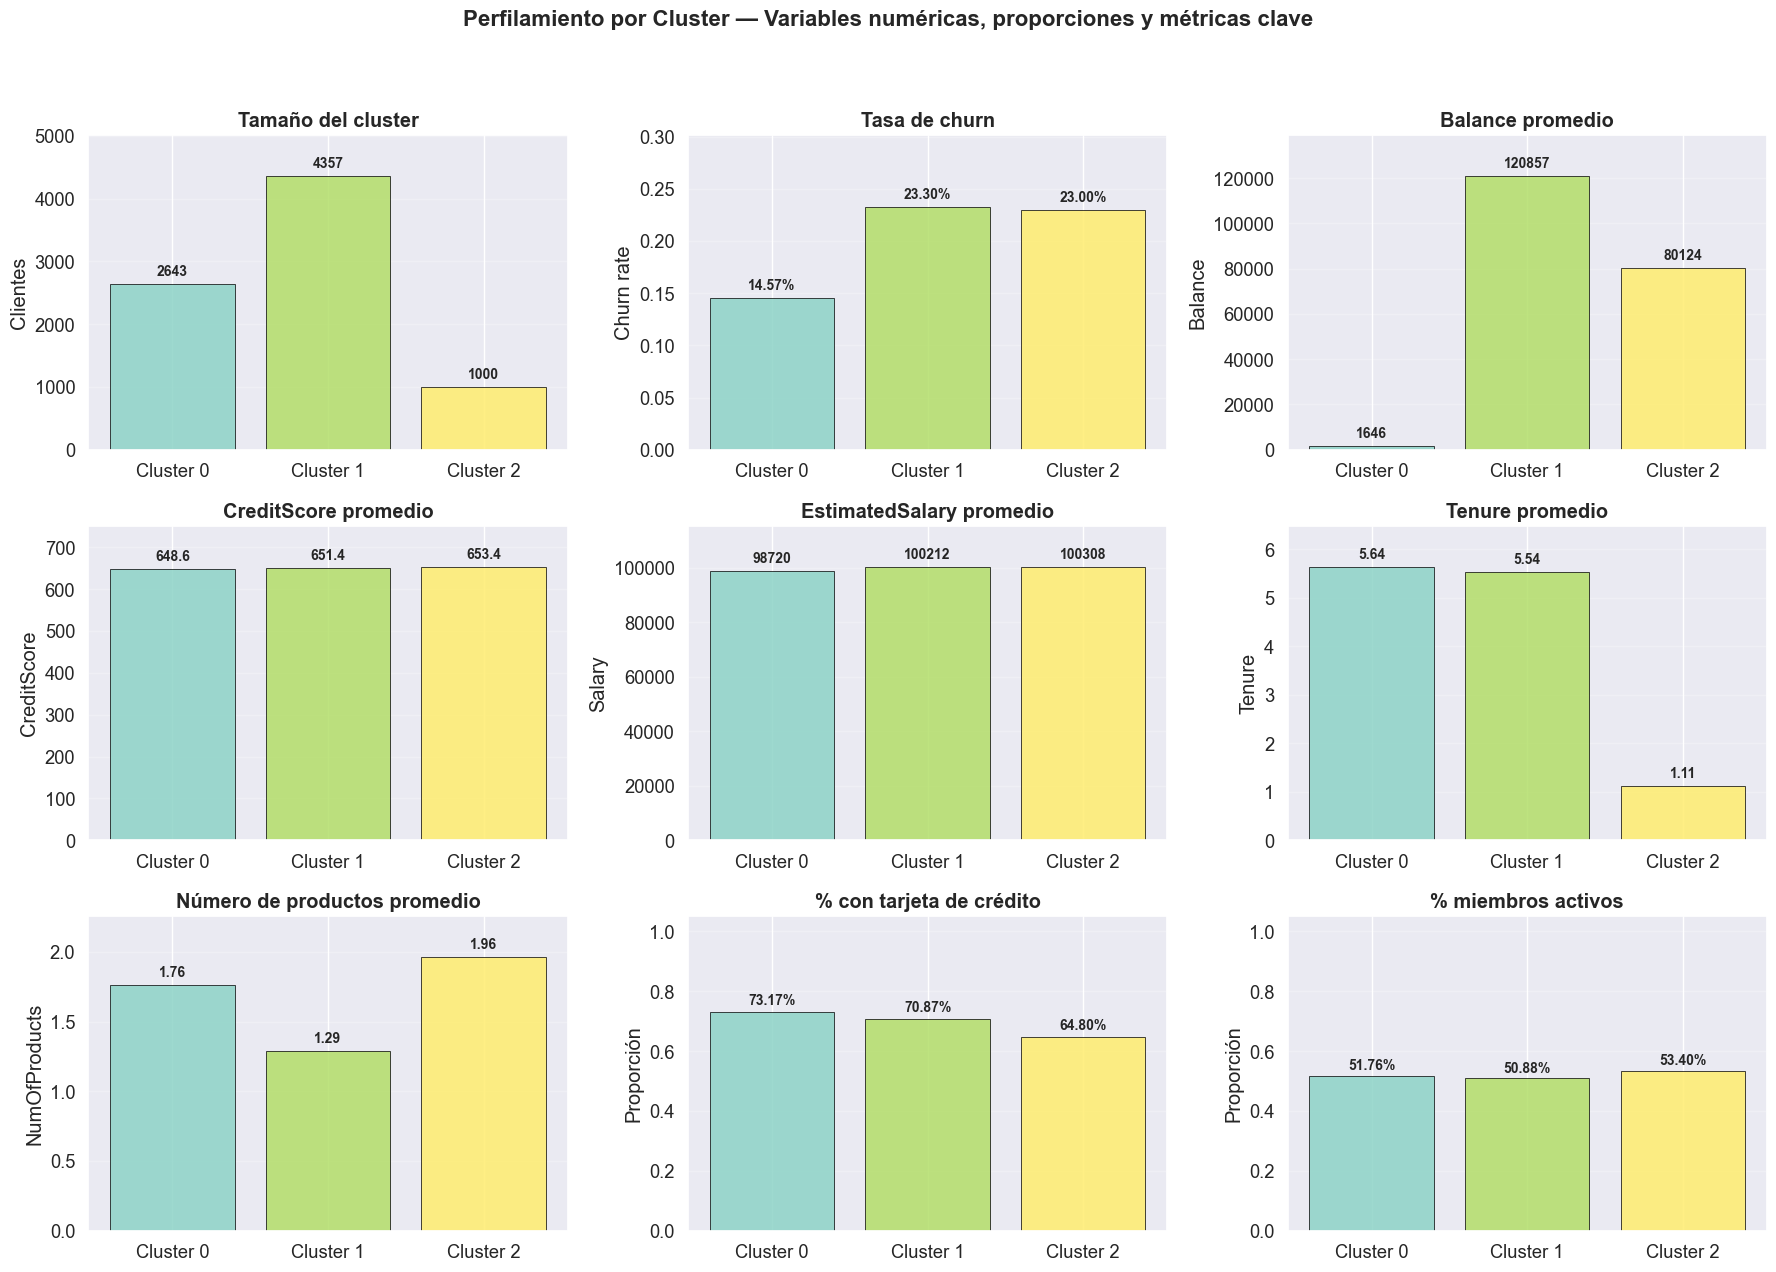

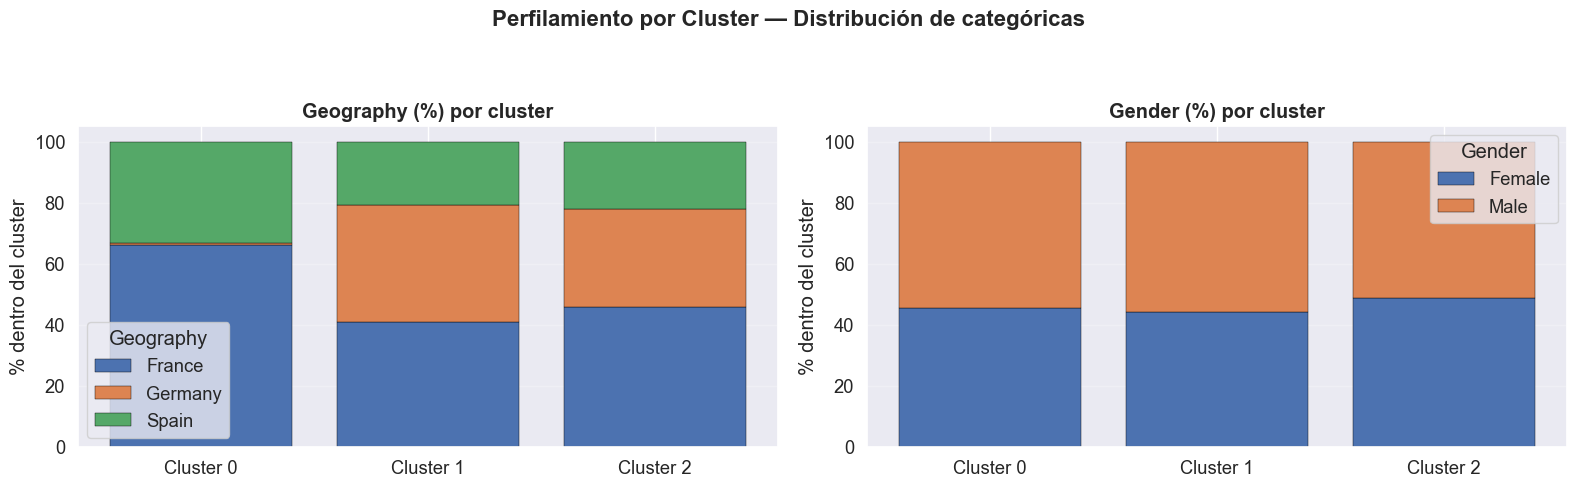

In [24]:
# Aseguramos nombres/colores si no existen
cluster_names = [f"Cluster {i}" for i in range(optimal_k)]
colors = plt.cm.Set3(np.linspace(0, 1, optimal_k))

# FIGURA A: Variables numéricas + porcentajes + métricas clave
fig, axes = plt.subplots(3, 3, figsize=(18, 13))
fig.suptitle("Perfilamiento por Cluster — Variables numéricas, proporciones y métricas clave",
             fontsize=16, fontweight="bold")

def bar_with_labels(ax, values, title, ylabel, fmt="{:.2f}", ylim_pad=1.15):
    bars = ax.bar(
        cluster_names,
        values,
        color=colors,
        edgecolor="black",
        linewidth=0.6,
        alpha=0.85
    )
    ax.set_title(title, fontweight="bold")
    ax.set_ylabel(ylabel)
    ax.grid(True, axis="y", alpha=0.25)

    vmax = np.nanmax(values)
    if vmax > 0:
        ax.set_ylim(0, vmax * ylim_pad)

    for b, v in zip(bars, values):
        ax.text(
            b.get_x() + b.get_width()/2,
            b.get_height() + (vmax * 0.02 if vmax > 0 else 0.01),
            fmt.format(v),
            ha="center", va="bottom",
            fontsize=10, fontweight="bold"
        )

cluster_profiles = {}

for cluster in range(optimal_k):
    cluster_subset = cluster_data[cluster_data["Cluster"] == cluster]

    cluster_profiles[f"Cluster_{cluster}"] = {
        "size": len(cluster_subset),
        "churn_rate": cluster_subset["Exited"].mean(),
        "avg_balance": cluster_subset["Balance"].mean(),
        "avg_credit_score": cluster_subset["CreditScore"].mean(),
        "avg_estimated_salary": cluster_subset["EstimatedSalary"].mean(),
        "avg_tenure": cluster_subset["Tenure"].mean(),
        "avg_num_products": cluster_subset["NumOfProducts"].mean(),
        "pct_has_credit_card": cluster_subset["HasCrCard"].mean(),
        "pct_active_member": cluster_subset["IsActiveMember"].mean(),
    }


# --- 1) Tamaño del cluster
cluster_sizes = [cluster_profiles[f"Cluster_{i}"]["size"] for i in range(optimal_k)]
bar_with_labels(axes[0, 0], cluster_sizes, "Tamaño del cluster", "Clientes", "{:.0f}")

# --- 2) Tasa de churn
churn_rates = [cluster_profiles[f"Cluster_{i}"]["churn_rate"] for i in range(optimal_k)]
bar_with_labels(axes[0, 1], churn_rates, "Tasa de churn", "Churn rate", "{:.2%}")
axes[0, 1].set_ylim(0, max(churn_rates) * 1.25 + 0.01)

# --- 3) Balance promedio
avg_balance = [cluster_profiles[f"Cluster_{i}"]["avg_balance"] for i in range(optimal_k)]
bar_with_labels(axes[0, 2], avg_balance, "Balance promedio", "Balance", "{:.0f}")

# --- 4) Credit Score promedio
avg_credit = [cluster_profiles[f"Cluster_{i}"]["avg_credit_score"] for i in range(optimal_k)]
bar_with_labels(axes[1, 0], avg_credit, "CreditScore promedio", "CreditScore", "{:.1f}")

# --- 5) Estimated Salary promedio
avg_salary = [cluster_profiles[f"Cluster_{i}"]["avg_estimated_salary"] for i in range(optimal_k)]
bar_with_labels(axes[1, 1], avg_salary, "EstimatedSalary promedio", "Salary", "{:.0f}")

# --- 6) Tenure promedio
avg_tenure = [cluster_profiles[f"Cluster_{i}"]["avg_tenure"] for i in range(optimal_k)]
bar_with_labels(axes[1, 2], avg_tenure, "Tenure promedio", "Tenure", "{:.2f}")

# --- 7) NumOfProducts promedio
avg_products = [cluster_profiles[f"Cluster_{i}"]["avg_num_products"] for i in range(optimal_k)]
bar_with_labels(axes[2, 0], avg_products, "Número de productos promedio", "NumOfProducts", "{:.2f}")

# --- 8) % con tarjeta de crédito
pct_cc = [cluster_profiles[f"Cluster_{i}"]["pct_has_credit_card"] for i in range(optimal_k)]
bar_with_labels(axes[2, 1], pct_cc, "% con tarjeta de crédito", "Proporción", "{:.2%}")
axes[2, 1].set_ylim(0, 1.05)

# --- 9) % activos
pct_active = [cluster_profiles[f"Cluster_{i}"]["pct_active_member"] for i in range(optimal_k)]
bar_with_labels(axes[2, 2], pct_active, "% miembros activos", "Proporción", "{:.2%}")
axes[2, 2].set_ylim(0, 1.05)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

# FIGURA B: Variables categóricas (Geography y Gender)
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("Perfilamiento por Cluster — Distribución de categóricas", fontsize=16, fontweight="bold")

# Geography: % por cluster (barras apiladas)
geo_ct = pd.crosstab(cluster_data["Cluster"], cluster_data["Geography"], normalize="index") * 100
geo_ct = geo_ct.reindex(range(optimal_k))  # por si falta alguno

bottom = np.zeros(optimal_k)
for col in geo_ct.columns:
    axes[0].bar(cluster_names, geo_ct[col].values, bottom=bottom, label=str(col), edgecolor="black", linewidth=0.3)
    bottom += geo_ct[col].values

axes[0].set_title("Geography (%) por cluster", fontweight="bold")
axes[0].set_ylabel("% dentro del cluster")
axes[0].grid(True, axis="y", alpha=0.25)
axes[0].legend(title="Geography")

# Gender: % por cluster (barras apiladas)
gender_ct = pd.crosstab(cluster_data["Cluster"], cluster_data["Gender"], normalize="index") * 100
gender_ct = gender_ct.reindex(range(optimal_k))

bottom = np.zeros(optimal_k)
for col in gender_ct.columns:
    axes[1].bar(cluster_names, gender_ct[col].values, bottom=bottom, label=str(col), edgecolor="black", linewidth=0.3)
    bottom += gender_ct[col].values

axes[1].set_title("Gender (%) por cluster", fontweight="bold")
axes[1].set_ylabel("% dentro del cluster")
axes[1].grid(True, axis="y", alpha=0.25)
axes[1].legend(title="Gender")

plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()



**Conclusiones:**

- **Similitudes**: entre los 3 clusters contienen un porcentaje en las siguientes variables:
    - *generos* siendo la 50% masculino y 50% feminino
    - *miembros activos* es del ~52%  
    - *Salario estimado promedio* es de ~$100.000
    - *Credit score* es de ~650

- **Diferencias**: 
    - *Size*: cluster 1 contiene el 54% de los clientes, cluster 0 el 33.04% y el cluster 2 el 12.50%
    - *Tasa de churn:* cluster 0 contiene un 16% en la tasa de churn, mientras que los clusters 1 y 2 contienen un 23% de abandonos.
    - *Balance:* cluster 0 1600, cluster 1 120.000 y cluster 2 80.000
    - *Tenere (años de antiguedad) promedio*: cluster 0 y 1 contiene 5,6 años en promedio mientras que el cluster 2 contiene 1,11.
    - *Numero de productos promedio*: cluster 2 contiene un promedio de 1.96, cluster 0 contiene 1.76 y el cluster 1 contiene en promedio 1.29.
    - *% con credit card*: cluster 0 contiene 73%, cluster 1 contiene 70% y cluster 2 contiene 64%.
    - *Geografia*: se puede destacar que en cluster 0 la mayor dominancia la tiene Francia 66% y 33% España, Alemania con 1% casi que no pertenece a este cluster. Los clusters 1 y 2 son muy similares en cuanto a la distribucion con ~40% Francia, ~40% Alemania y 20% España 

### 4.6 Perfilamiento por cluster

In [25]:
# 1) Aplicar clustering al conjunto completo
X_full = pd.concat([X_train_processed, X_test_processed], axis=0)
y_full = pd.concat([y_train, y_test], axis=0)

print(f"Dataset completo para clustering: {X_full.shape}")

# Re-entrenar K-Means en conjunto completo

best_k = kmeans_final.n_clusters if "kmeans_final" in globals() else 3

kmeans_full = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init="auto"
)

full_labels = kmeans_full.fit_predict(X_full)
X_full_clustered = X_full.copy()
X_full_clustered["Cluster"] = full_labels

# Features derivadas

print("\nCreando features derivadas del clustering...")

# Cluster asignado (one-hot) variables binarias con cluster_0, cluster_1, cluster_2
cluster_ohe = pd.get_dummies(full_labels, prefix="cluster")
cluster_ohe.index = X_full_clustered.index

# Distancia al centroide del cluster asignado
centroids = kmeans_full.cluster_centers_
distances_to_centroids = pairwise_distances(X_full, centroids)
assigned_centroid_dist = distances_to_centroids[np.arange(len(X_full)), full_labels]

# calcular tasa de churn por cluster
cluster_churn_rate = (
    pd.DataFrame({"cluster": full_labels, "Exited": y_full.values})
    .groupby("cluster")["Exited"]
    .mean()
)

high_risk_cluster = cluster_churn_rate.idxmax()
print(f"\nCluster de mayor riesgo de churn: {high_risk_cluster}")
print("Tasa de churn por cluster:")
display(cluster_churn_rate)

# distancia al centroide del cluster de mayor churn
high_risk_centroid = centroids[high_risk_cluster]
distance_to_high_risk_cluster = pairwise_distances(
    X_full, high_risk_centroid.reshape(1, -1)
).ravel()

# Indicador de pertenencia a cluster de alto riesgo
is_high_risk_cluster = (full_labels == high_risk_cluster).astype(int)

# Score de riesgo basado en cluster (tasa de churn del cluster)
cluster_risk_score = cluster_churn_rate.loc[full_labels].values

# Unir nuevas features al dataset original
derived_features = pd.DataFrame({
    "cluster_id": full_labels,
    "dist_to_own_centroid": assigned_centroid_dist,
    "dist_to_high_risk_centroid": distance_to_high_risk_cluster,
    "is_high_risk_cluster": is_high_risk_cluster,
    "cluster_churn_risk_score": cluster_risk_score
}, index=X_full.index)

X_full_enriched = pd.concat([X_full, cluster_ohe, derived_features], axis=1)

print(f"\nNuevo shape con features derivadas: {X_full_enriched.shape}")

# 5) Mostrar estadísticas de las nuevas features

print("\nEstadísticas descriptivas de features derivadas:")
display(X_full_enriched[
    ["dist_to_own_centroid", "dist_to_high_risk_centroid",
     "is_high_risk_cluster", "cluster_churn_risk_score"]
].describe())


Dataset completo para clustering: (10000, 17)

Creando features derivadas del clustering...

Cluster de mayor riesgo de churn: 1
Tasa de churn por cluster:


cluster
0    0.156530
1    0.230428
2    0.202141
Name: Exited, dtype: float64


Nuevo shape con features derivadas: (10000, 25)

Estadísticas descriptivas de features derivadas:


,dist_to_own_centroid,dist_to_high_risk_centroid,is_high_risk_cluster,cluster_churn_risk_score
count,10000.000000,10000.000000,10000.000000,10000.000000
mean,2.537406,3.067003,0.540300,0.203700
std,0.612125,0.901386,0.498398,0.032495
min,1.159965,1.185769,0.000000,0.156530
25%,2.129524,2.423689,0.000000,0.156530
50%,2.466642,3.002964,1.000000,0.230428
75%,2.840726,3.537573,1.000000,0.230428
max,6.950714,9.549796,1.000000,0.230428


Con estas features logro obtener la siguiente informacion:

- “A qué cluster pertenezco”
- dist_to_own_centroid -> “Qué tan típico soy dentro del cluster”
- dist_to_high_risk_centroid -> “Qué tan cerca estoy del cluster que más churn tiene”
- cluster_churn_risk_score -> “Mi riesgo de churn por el cluster donde estoy”

### 4.7 Visualización de features derivadas en k-means

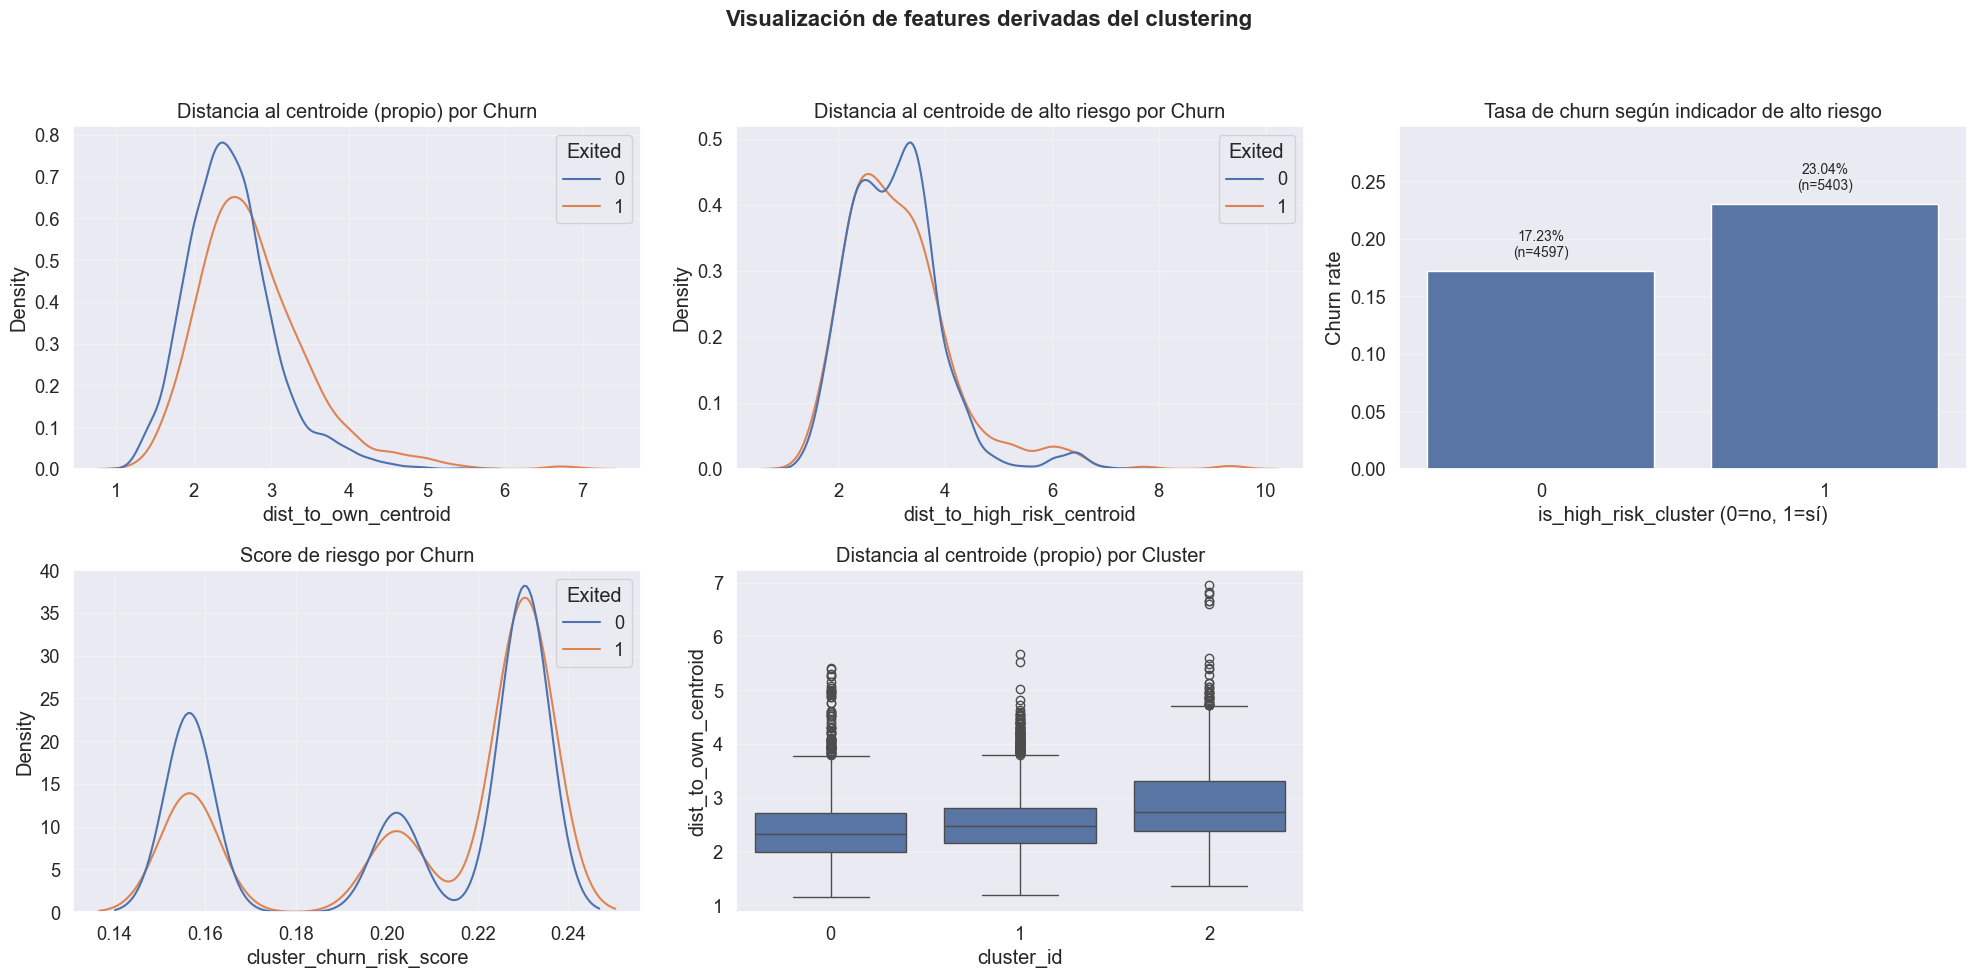


Shapes finales enriquecidos:
X_train_enriched: (8000, 25) | y_train_enriched: (8000,)
X_test_enriched : (2000, 25) | y_test_enriched : (2000,)
✅ Índices alineados correctamente.


In [26]:
# =========================================================
# DF de visualización
# =========================================================
df_vis = X_full_enriched[[
    "cluster_id",
    "dist_to_own_centroid",
    "dist_to_high_risk_centroid",
    "is_high_risk_cluster",
    "cluster_churn_risk_score"
]].copy()

df_vis["Exited"] = y_full.values

# =========================================================
# Preparar datos para barplot (tasa churn por indicador)
# =========================================================
churn_rate_by_risk = df_vis.groupby("is_high_risk_cluster")["Exited"].mean().rename("churn_rate")
counts_by_risk = df_vis["is_high_risk_cluster"].value_counts().sort_index()

plot_df = pd.DataFrame({
    "is_high_risk_cluster": churn_rate_by_risk.index.astype(int),
    "churn_rate": churn_rate_by_risk.values,
    "count": counts_by_risk.values
})

# =========================================================
# Todos los gráficos en una sola figura
# =========================================================
fig, axes = plt.subplots(2, 3, figsize=(20, 10))
fig.suptitle("Visualización de features derivadas del clustering", fontsize=16, fontweight="bold")

# 1) KDE dist_to_own_centroid por churn
sns.kdeplot(data=df_vis, x="dist_to_own_centroid", hue="Exited", common_norm=False, ax=axes[0, 0])
axes[0, 0].set_title("Distancia al centroide (propio) por Churn")
axes[0, 0].set_xlabel("dist_to_own_centroid")
axes[0, 0].grid(True, alpha=0.3)

# 2) KDE dist_to_high_risk_centroid por churn
sns.kdeplot(data=df_vis, x="dist_to_high_risk_centroid", hue="Exited", common_norm=False, ax=axes[0, 1])
axes[0, 1].set_title("Distancia al centroide de alto riesgo por Churn")
axes[0, 1].set_xlabel("dist_to_high_risk_centroid")
axes[0, 1].grid(True, alpha=0.3)

# 3) Barplot churn rate por indicador de alto riesgo (con etiquetas)
ax_bar = sns.barplot(data=plot_df, x="is_high_risk_cluster", y="churn_rate", ax=axes[0, 2])
axes[0, 2].set_title("Tasa de churn según indicador de alto riesgo")
axes[0, 2].set_xlabel("is_high_risk_cluster (0=no, 1=sí)")
axes[0, 2].set_ylabel("Churn rate")
axes[0, 2].set_ylim(0, min(1, plot_df["churn_rate"].max() * 1.25 + 0.01))
axes[0, 2].grid(True, axis="y", alpha=0.3)

for i, row in plot_df.iterrows():
    ax_bar.text(
        i,
        row["churn_rate"] + 0.01,
        f"{row['churn_rate']:.2%}\n(n={int(row['count'])})",
        ha="center",
        va="bottom",
        fontsize=10
    )

# 4) KDE cluster_churn_risk_score por churn
sns.kdeplot(data=df_vis, x="cluster_churn_risk_score", hue="Exited", common_norm=False, ax=axes[1, 0])
axes[1, 0].set_title("Score de riesgo por Churn")
axes[1, 0].set_xlabel("cluster_churn_risk_score")
axes[1, 0].grid(True, alpha=0.3)

# 5) Boxplot dist_to_own_centroid por cluster
sns.boxplot(data=df_vis, x="cluster_id", y="dist_to_own_centroid", ax=axes[1, 1])
axes[1, 1].set_title("Distancia al centroide (propio) por Cluster")
axes[1, 1].set_xlabel("cluster_id")
axes[1, 1].set_ylabel("dist_to_own_centroid")
axes[1, 1].grid(True, axis="y", alpha=0.3)

# 6) Dejar el último subplot vacío (o podés poner el heatmap acá si querés)
axes[1, 2].axis("off")
axes[1, 2].set_title("")

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

# =========================================================
# Separar features para train y test (igual que antes)
# =========================================================
train_idx = X_train_processed.index
test_idx = X_test_processed.index

X_train_enriched = X_full_enriched.loc[train_idx].copy()
X_test_enriched  = X_full_enriched.loc[test_idx].copy()

y_train_enriched = y_full.loc[train_idx].copy()
y_test_enriched  = y_full.loc[test_idx].copy()

print("\nShapes finales enriquecidos:")
print("X_train_enriched:", X_train_enriched.shape, "| y_train_enriched:", y_train_enriched.shape)
print("X_test_enriched :", X_test_enriched.shape,  "| y_test_enriched :", y_test_enriched.shape)

assert (X_train_enriched.index == y_train_enriched.index).all()
assert (X_test_enriched.index == y_test_enriched.index).all()
print("✅ Índices alineados correctamente.")


**Conclusiones segun los graficos:**

- *Distancia al centroide propio por churn:* los clientes con churn estan desplazados hacia la derecha, lo que indica que los clientes que mayor probabilidad de abandonar son los mas lejanos al centroide.

- *Distancia al centroide de alto riesgo por churn:* Los clientes que abandonan están ligeramente más cerca del centroide del cluster de alto riesgo, es decir que cuanto más cerca estás del “perfil peligroso”,
más chances tenés de abandonar.

- *Tasa de churn segun indicador de alto riesgo:* estar en el cluster de mayor riesgo de churn indica que aumentan las probabilidades un 33% aproximadamente.

- *Score de riesgo por churn*: El score de riesgo basado en la tasa histórica de churn del cluster muestra una clara separación entre churners y no-churners

- *Distancia al centroide propio por cluster:* Cluster 2 es el más heterogéneo e inestable. Cluster 0 es el más coherente y estable. Cluster 1 es un intermedio entre el 0 y el 2. Los clusters más dispersos (especialmente el cluster 2) concentran mayor inestabilidad y mayor churn

## 5. DBSCAN

Permite agrupar los clusters segun:
* eps -> hasta que distancia considero que 2 puntos estan cerca.
* min_samples -> cant. minima de puntos necesito cerca para formar un cluster.


=== APLICACIÓN DBSCAN ===
DBSCAN requiere determinar parámetros eps y min_samples

Usando min_samples = 8 (heurística)


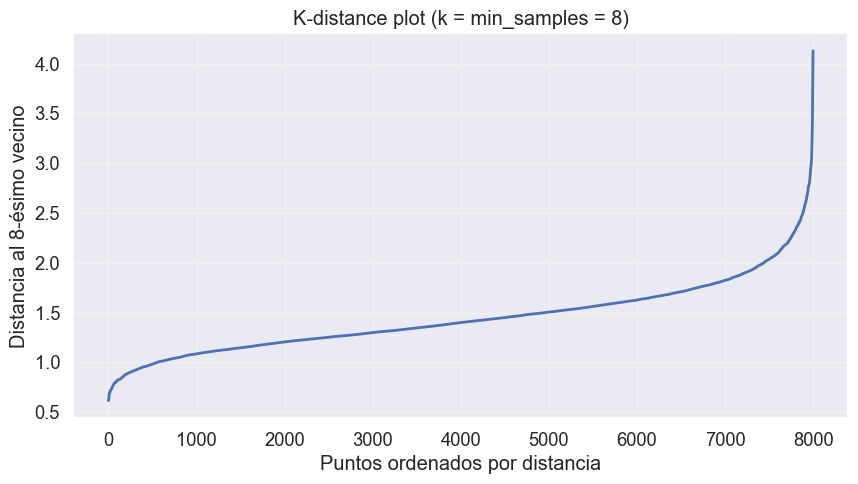


👉 En este gráfico buscá el 'codo'. El valor de eps suele estar cerca de esa altura (eje Y).


In [27]:
## Aplicación de DBSCAN
print("\n=== APLICACIÓN DBSCAN ===")
print("DBSCAN requiere determinar parámetros eps y min_samples")

# Determinamos eps usando k-distance plot
min_samples = 8
print(f"\nUsando min_samples = {min_samples} (heurística)")

# NearestNeighbors para k-distances (k = min_samples)
nbrs = NearestNeighbors(n_neighbors=min_samples, metric="euclidean", n_jobs=-1)
nbrs.fit(X_clustering)

#Obtenemos la distancia de los vecinos mas cercanos
distances, _ = nbrs.kneighbors(X_clustering)

# Nos quedamos con la distancia al k-ésimo vecino (última columna)
k_distances = np.sort(distances[:, -1])

plt.figure(figsize=(10, 5))
plt.plot(k_distances, linewidth=2)
plt.title(f'K-distance plot (k = min_samples = {min_samples})')
plt.xlabel('Puntos ordenados por distancia')
plt.ylabel(f'Distancia al {min_samples}-ésimo vecino')
plt.grid(True, alpha=0.3)
plt.show()

print("\n👉 En este gráfico buscá el 'codo'. El valor de eps suele estar cerca de esa altura (eje Y).")

Se puede observar un codo para una distancia aproximada de 2. Por lo tanto, se selecciona un eps = 2.2

### 5.1 Determinar eps segun metodo del codo

In [28]:
# Determinar eps (buscar el "codo" en la gráfica)
# Seleccionar mejor eps

best_eps = 2.2
print(f"\n✅ Mejor configuración elegida: eps={best_eps:.4f}, min_samples={min_samples}")

# Entrenar DBSCAN final
dbscan_final = DBSCAN(eps=best_eps, min_samples=min_samples, metric="euclidean", n_jobs=-1)
dbscan_labels = dbscan_final.fit_predict(X_clustering)

# Guardar labels en un DF aparte (recomendado) o en X_clustering si querés
X_clustering_dbscan = X_clustering.copy()
X_clustering_dbscan["DBSCAN_Cluster"] = dbscan_labels

print("\nDistribución de etiquetas DBSCAN:")
print(pd.Series(dbscan_labels).value_counts().sort_index())

# Separación ruido vs clusters
n_noise = (dbscan_labels == -1).sum()
print(f"\nPuntos ruidosos (label=-1): {n_noise} / {len(dbscan_labels)} ({n_noise/len(dbscan_labels):.2%})")



✅ Mejor configuración elegida: eps=2.2000, min_samples=8

Distribución de etiquetas DBSCAN:
-1     105
 0    7779
 1     116
Name: count, dtype: int64

Puntos ruidosos (label=-1): 105 / 8000 (1.31%)


A partir de *eps* = 2.2 (distancia al vecino minima) y *min_samples* = 8 (cantidad minima de puntos necesarios) se obtuvieron: 
- **2 clusters**: cluster 0 con 7779 (97%) y cluster 1 con 116 (1.45%).
- **Ruido** de 105 que representa el (1.31%)

Se interpreta que:
- Los datos son más bien homogéneos
- No hay fronteras claras entre perfiles
- Solo hay outliers reales y un microsegmento raros

### 5.2 Grafico de PCA y T-sne para DBSCAN


=== PCA + t-SNE para DBSCAN ===


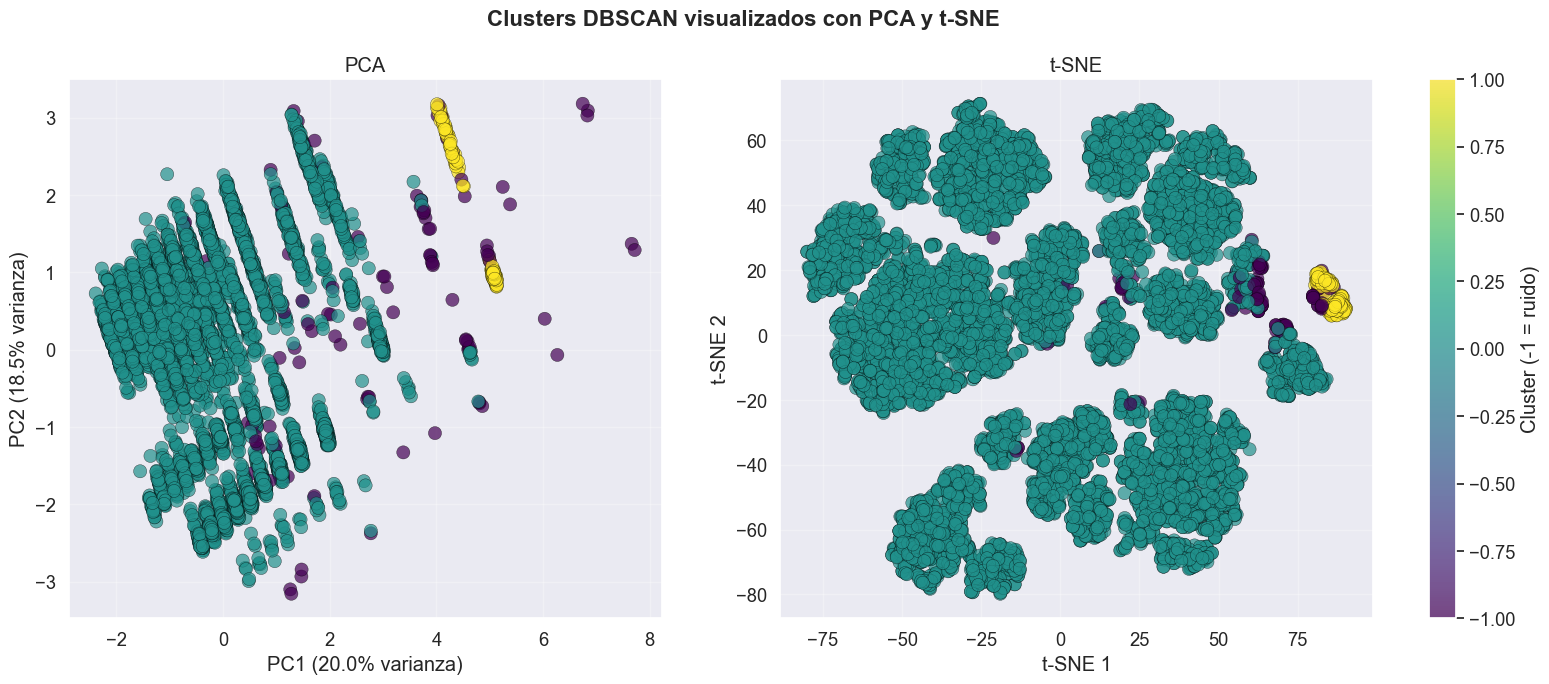

In [29]:
print("\n=== PCA + t-SNE para DBSCAN ===")

# PCA 
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_clustering)

df_pca = pd.DataFrame(
    X_pca,
    columns=["PC1", "PC2"],
    index=X_clustering.index
)
df_pca["DBSCAN_Cluster"] = dbscan_labels

var_pc1 = pca.explained_variance_ratio_[0] * 100
var_pc2 = pca.explained_variance_ratio_[1] * 100

# t-SNE 
tsne_idx = X_clustering.index.values
X_tsne_input = X_clustering
labels_tsne = dbscan_labels
    
perplexity = 30

tsne = TSNE(
    n_components=2,
    random_state=42,
    perplexity=perplexity,
    learning_rate="auto",
    init="pca"
)

X_tsne = tsne.fit_transform(X_tsne_input)

# 3) Plot unificado
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle("Clusters DBSCAN visualizados con PCA y t-SNE", fontsize=16, fontweight="bold")

# PCA subplot
sc1 = axes[0].scatter(
    df_pca["PC1"], df_pca["PC2"],
    c=df_pca["DBSCAN_Cluster"],
    cmap="viridis",
    s=90,
    alpha=0.7,
    edgecolors="black",
    linewidths=0.3
)

axes[0].set_title("PCA")
axes[0].set_xlabel(f"PC1 ({var_pc1:.1f}% varianza)")
axes[0].set_ylabel(f"PC2 ({var_pc2:.1f}% varianza)")
axes[0].grid(True, alpha=0.3)

# t-SNE subplot
sc2 = axes[1].scatter(
    X_tsne[:, 0], X_tsne[:, 1],
    c=labels_tsne,
    cmap="viridis",
    s=90,
    alpha=0.7,
    edgecolors="black",
    linewidths=0.3
)

axes[1].set_title("t-SNE")
axes[1].set_xlabel("t-SNE 1")
axes[1].set_ylabel("t-SNE 2")
axes[1].grid(True, alpha=0.3)

# Colorbar compartida
cbar = fig.colorbar(sc1, ax=axes, orientation="vertical", fraction=0.025, pad=0.04)
cbar.set_label("Cluster (-1 = ruido)")
plt.show()

Se puede visualizar en el grafico que cada punto es un cliente:
- -1 (morado oscuro) → ruido / outliers
- 0 (verde-azulado) → cluster principal
- 1 (amarillo) → cluster secundario chico

En PCA:
- Casi todos los puntos están mezclados en una gran nube
- Un pequeño grupo (amarillo) aparece separado a la derecha
- Algunos puntos dispersos → ruido real

En t-SNE:
- Hay muchas “islas visuales”
- Pero todas esas islas tienen el mismo color (cluster 0)
- Solo una islita compacta (amarilla) es cluster 1
- Puntos violeta sueltos → ruido

En conclusion: DBSCAN NO encontró 3, 4 o 5 clusters bien definidos


## 6. Comparaciones DBSCAN y K-Means

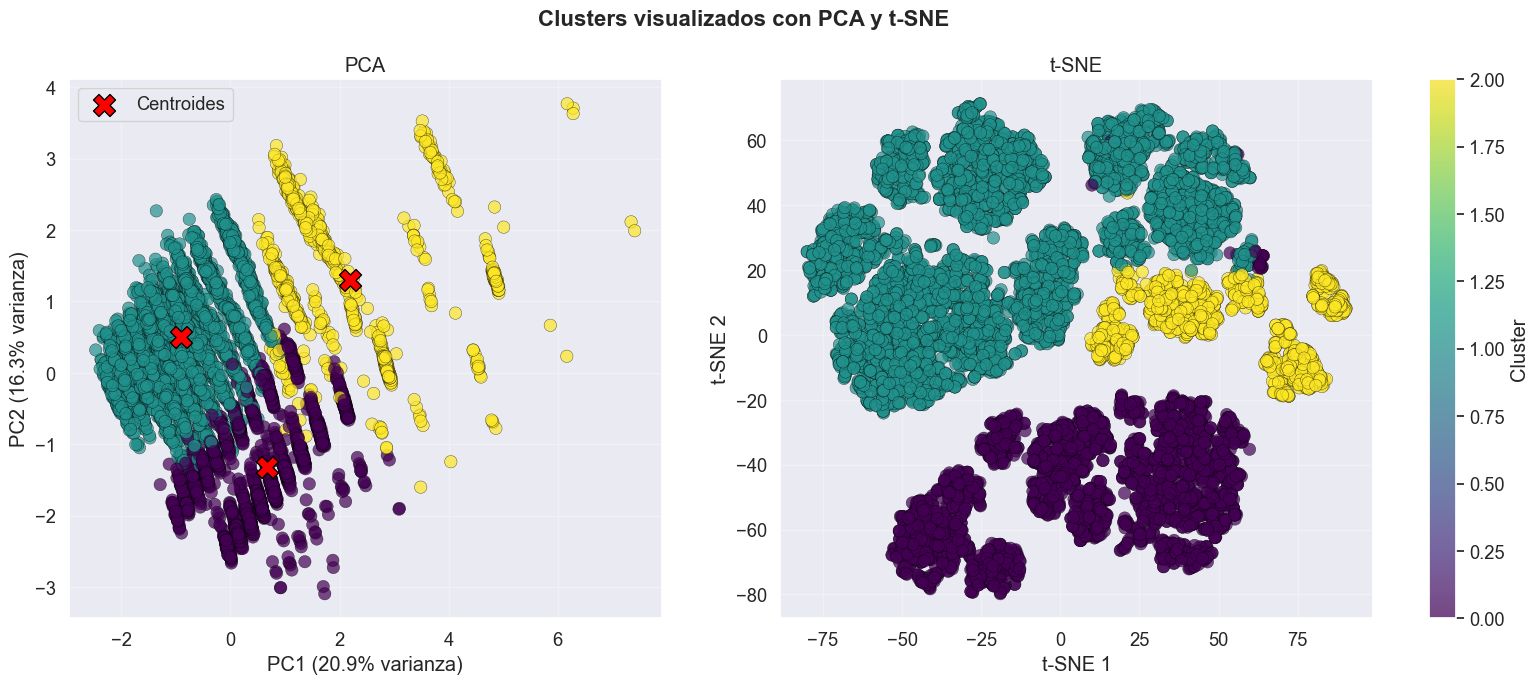

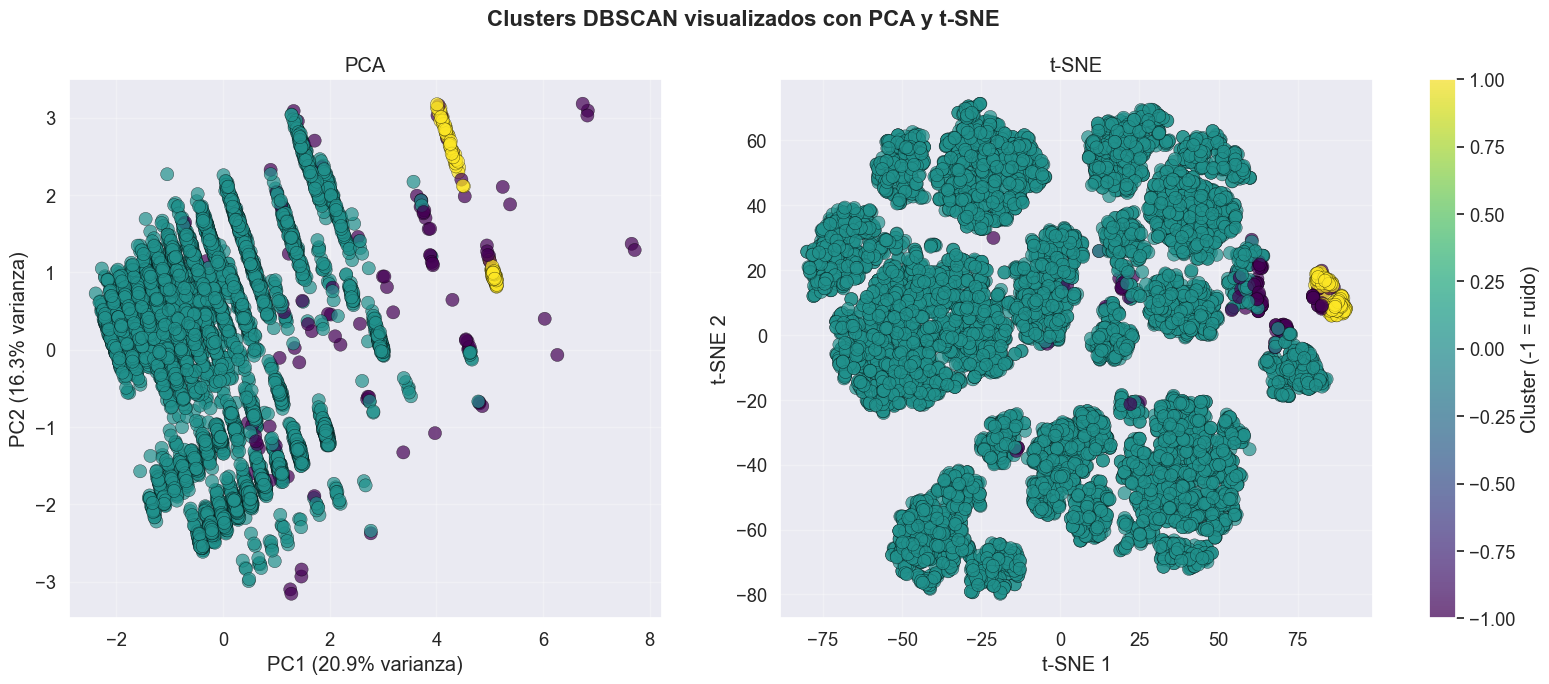

In [ ]:
# PCA: resumo los datos en 2 columnas 
pca_vis = PCA(n_components=2, random_state=42)

# se elimina el target ya que no es necesario
# errors="ignore" -> evita errores si la columna no existe
X_pca = pca_vis.fit_transform(X_clustering.drop(columns=["Cluster"], errors="ignore")) 

#Obtengo los centroides para dibujarlos
centroids_original = kmeans_final.cluster_centers_
centroids_pca = pca_vis.transform(centroids_original)

#Varianza de cada columna
var_pc1 = pca_vis.explained_variance_ratio_[0] * 100
var_pc2 = pca_vis.explained_variance_ratio_[1] * 100

#============================

# t-SNE 

#Asignamos variables para t-SNE
tsne_idx = X_clustering.index.values
X_tsne_input = X_clustering
labels_tsne = kmeans_labels

#Definimos perplexity
perplexity = 30

#Creamos tsne y transformamos el X_tsne
tsne = TSNE(
    n_components=2,
    random_state=42,
    perplexity=perplexity,
    learning_rate="auto",
)

X_tsne = tsne.fit_transform(X_tsne_input)


# Plot unificado
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle("Clusters visualizados con PCA y t-SNE", fontsize=16, fontweight="bold")

# PCA subplot
sc1 = axes[0].scatter(
    X_pca[:, 0], X_pca[:, 1],
    c=kmeans_labels,
    cmap="viridis",
    s=80,
    alpha=0.7,
    edgecolors="black",
    linewidths=0.3
)

axes[0].scatter(
    centroids_pca[:, 0], centroids_pca[:, 1],
    c="red",
    s=250,
    marker="X",
    edgecolors="black",
    label="Centroides"
)

axes[0].set_title("PCA")
axes[0].set_xlabel(f"PC1 ({var_pc1:.1f}% varianza)")
axes[0].set_ylabel(f"PC2 ({var_pc2:.1f}% varianza)")
axes[0].grid(True, alpha=0.3)
axes[0].legend()

# t-SNE subplot
sc2 = axes[1].scatter(
    X_tsne[:, 0], X_tsne[:, 1],
    c=labels_tsne,
    cmap="viridis",
    s=80,
    alpha=0.7,
    edgecolors="black",
    linewidths=0.3
)

axes[1].set_title("t-SNE")
axes[1].set_xlabel("t-SNE 1")
axes[1].set_ylabel("t-SNE 2")
axes[1].grid(True, alpha=0.3)

# Colorbar compartida
cbar = fig.colorbar(sc1, ax=axes, orientation="vertical", fraction=0.025, pad=0.04)
cbar.set_label("Cluster")

plt.show()

#################
#DBSCAN

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle("Clusters DBSCAN visualizados con PCA y t-SNE", fontsize=16, fontweight="bold")

# PCA subplot
sc1 = axes[0].scatter(
    df_pca["PC1"], df_pca["PC2"],
    c=df_pca["DBSCAN_Cluster"],
    cmap="viridis",
    s=90,
    alpha=0.7,
    edgecolors="black",
    linewidths=0.3
)

axes[0].set_title("PCA")
axes[0].set_xlabel(f"PC1 ({var_pc1:.1f}% varianza)")
axes[0].set_ylabel(f"PC2 ({var_pc2:.1f}% varianza)")
axes[0].grid(True, alpha=0.3)

# t-SNE subplot
sc2 = axes[1].scatter(
    X_tsne[:, 0], X_tsne[:, 1],
    c=df_pca["DBSCAN_Cluster"],
    cmap="viridis",
    s=90,
    alpha=0.7,
    edgecolors="black",
    linewidths=0.3
)

axes[1].set_title("t-SNE")
axes[1].set_xlabel("t-SNE 1")
axes[1].set_ylabel("t-SNE 2")
axes[1].grid(True, alpha=0.3)

# Colorbar compartida
cbar = fig.colorbar(sc1, ax=axes, orientation="vertical", fraction=0.025, pad=0.04)
cbar.set_label("Cluster (-1 = ruido)")
plt.show()

Conclusiones para algoritmo PCA (estructura global) + t-SNE (estructura local):
- K-Means: 
    - PCA: 3 clusters visibles y separados
    - t-SNE: 3 grupos compactos bien definidos
- DBSCAN:
	- PCA: 1 nube masiva + micro-cluster + ruido
    - t-SNE: 1 mega-grupo + una islita + puntos sueltos

K-Means identifica tres segmentos de clientes bien definidos y estables, mientras que DBSCAN colapsa casi toda la base en un único cluster y solo detecta un pequeño grupo extremo y algunos outliers, lo que indica que la estructura natural del dataset es continua y no presenta regiones de alta densidad separadas.

## 7. Evaluación final de clustering

In [31]:
print(f"\n=== EVALUACIÓN FINAL DE CLUSTERING ===")

# Labels finales
labels_km = kmeans_labels if "kmeans_labels" in globals() else kmeans_full.labels_
labels_db = dbscan_labels

# Métricas finales K-Means
km_n_clusters = len(np.unique(labels_km))
km_sil = silhouette_score(X_clustering, labels_km)
km_ch  = calinski_harabasz_score(X_clustering, labels_km)
km_db  = davies_bouldin_score(X_clustering, labels_km)

print("\n--- K-MEANS ---")
print(f"N° de clusters        : {km_n_clusters}")
print(f"Silhouette Score      : {km_sil:.4f}")
print(f"Calinski-Harabasz     : {km_ch:.2f}")
print(f"Davies-Bouldin        : {km_db:.4f}")

# Métricas DBSCAN (solo puntos no ruidosos)
mask_db = labels_db != -1
db_noise_ratio = 1 - mask_db.mean()
db_unique_clusters = sorted(set(labels_db) - {-1})
db_n_clusters = len(db_unique_clusters)

if db_n_clusters >= 2 and mask_db.sum() >= 10:
    db_sil = silhouette_score(X_clustering[mask_db], labels_db[mask_db])
    db_ch  = calinski_harabasz_score(X_clustering[mask_db], labels_db[mask_db])
    db_db  = davies_bouldin_score(X_clustering[mask_db], labels_db[mask_db])
else:
    db_sil = np.nan
    db_ch  = np.nan
    db_db  = np.nan

print("\n--- DBSCAN ---")
print(f"N° de clusters        : {db_n_clusters}")
print(f"Proporción de ruido   : {db_noise_ratio:.2%}")
print(f"Silhouette (sin ruido): {db_sil}")
print(f"Calinski-Harabasz     : {db_ch}")
print(f"Davies-Bouldin        : {db_db}")

# Resumen comparativo
summary_df = pd.DataFrame({
    "Modelo": ["K-Means", "DBSCAN"],
    "N_clusters": [km_n_clusters, db_n_clusters],
    "Silhouette": [km_sil, db_sil],
    "Calinski_Harabasz": [km_ch, db_ch],
    "Davies_Bouldin": [km_db, db_db],
    "Noise_ratio": [0.0, db_noise_ratio]
})

print("\nResumen comparativo final:")
display(summary_df)



=== EVALUACIÓN FINAL DE CLUSTERING ===

--- K-MEANS ---
N° de clusters        : 3
Silhouette Score      : 0.1994
Calinski-Harabasz     : 1560.30
Davies-Bouldin        : 1.7637

--- DBSCAN ---
N° de clusters        : 2
Proporción de ruido   : 1.31%
Silhouette (sin ruido): 0.3703555943632767
Calinski-Harabasz     : 400.73192636282727
Davies-Bouldin        : 0.9282485064910543

Resumen comparativo final:


,Modelo,N_clusters,Silhouette,Calinski_Harabasz,Davies_Bouldin,Noise_ratio
0,K-Means,3,0.199399,1560.304260,1.763657,0.000000
1,DBSCAN,2,0.370356,400.731926,0.928249,0.013125


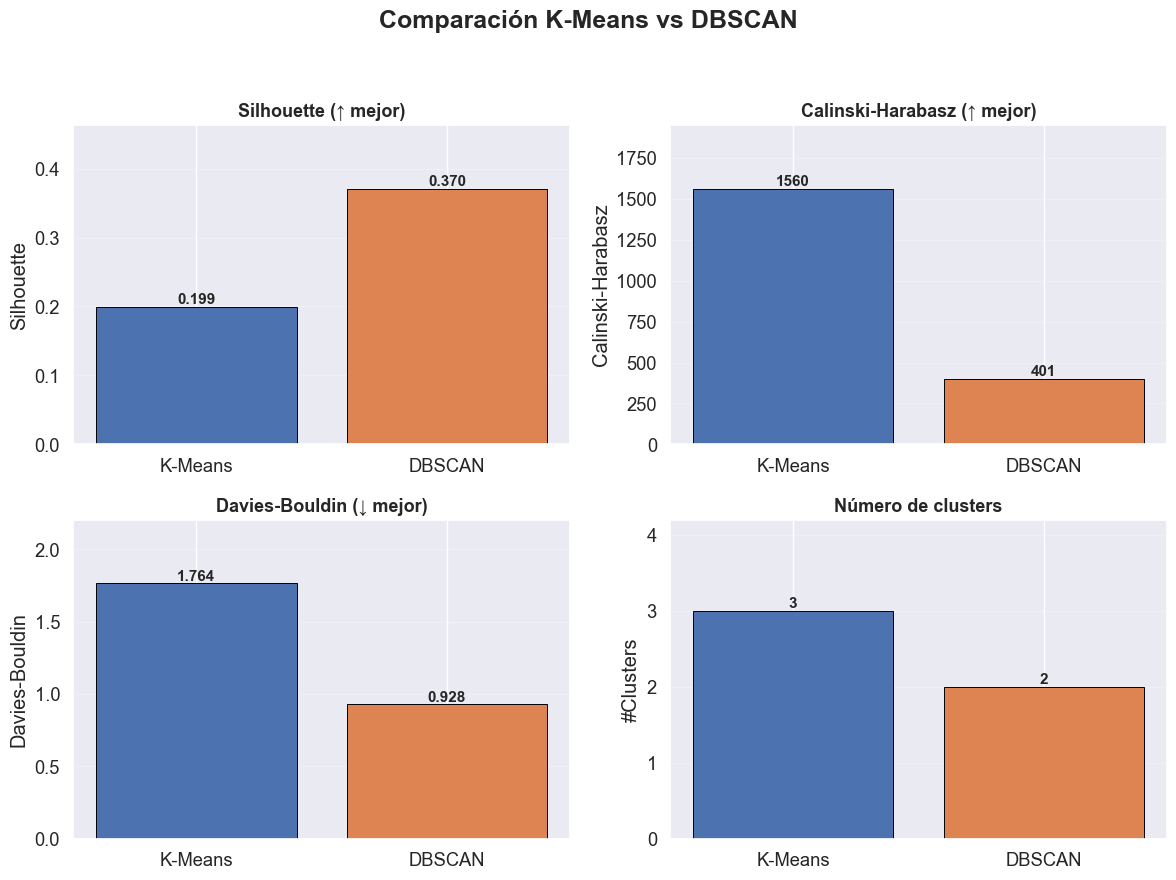

In [32]:
models = ["K-Means", "DBSCAN"]
colors = ["#4C72B0", "#DD8452"]  # azul / naranja suaves

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
fig.suptitle("Comparación K-Means vs DBSCAN", fontsize=18, fontweight="bold")

def add_labels(ax, values, fmt="{:.2f}"):
    for i, v in enumerate(values):
        if not np.isnan(v):
            ax.text(
                i, v,
                fmt.format(v),
                ha="center", va="bottom",
                fontsize=11, fontweight="bold"
            )

# Gráfico Silhouette (↑ mejor)
vals = [km_sil, db_sil]
bars = axes[0, 0].bar(models, vals, color=colors, edgecolor="black", linewidth=0.7)
axes[0, 0].set_title("Silhouette (↑ mejor)", fontsize=13, fontweight="bold")
axes[0, 0].set_ylabel("Silhouette")
axes[0, 0].set_ylim(0, max(vals) * 1.25)
axes[0, 0].grid(True, axis="y", alpha=0.25)
add_labels(axes[0, 0], vals, "{:.3f}")

# Gráfico Calinski-Harabasz (↑ mejor)
vals = [km_ch, db_ch]
bars = axes[0, 1].bar(models, vals, color=colors, edgecolor="black", linewidth=0.7)
axes[0, 1].set_title("Calinski-Harabasz (↑ mejor)", fontsize=13, fontweight="bold")
axes[0, 1].set_ylabel("Calinski-Harabasz")
axes[0, 1].set_ylim(0, max(vals) * 1.25)
axes[0, 1].grid(True, axis="y", alpha=0.25)
add_labels(axes[0, 1], vals, "{:.0f}")

# Gráfico Davies-Bouldin (↓ mejor)
vals = [km_db, db_db]
bars = axes[1, 0].bar(models, vals, color=colors, edgecolor="black", linewidth=0.7)
axes[1, 0].set_title("Davies-Bouldin (↓ mejor)", fontsize=13, fontweight="bold")
axes[1, 0].set_ylabel("Davies-Bouldin")
axes[1, 0].set_ylim(0, max(vals) * 1.25)
axes[1, 0].grid(True, axis="y", alpha=0.25)
add_labels(axes[1, 0], vals, "{:.3f}")

# Gráfico Número de clusters
vals = [km_n_clusters, db_n_clusters]
bars = axes[1, 1].bar(models, vals, color=colors, edgecolor="black", linewidth=0.7)
axes[1, 1].set_title("Número de clusters", fontsize=13, fontweight="bold")
axes[1, 1].set_ylabel("#Clusters")
axes[1, 1].set_ylim(0, max(vals) * 1.4)
axes[1, 1].grid(True, axis="y", alpha=0.25)
add_labels(axes[1, 1], vals, "{:.0f}")

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

**Silhouette Score (↑ mejor)**: qué tan bien separado está cada punto de su propio cluster
- K-Means: 0.199
- DBSCAN: 0.370 (mejor)

**Calinski-Harabasz (↑ mejor)**: qué tan compactos son los clusters internamente
- K-Means: 1560 (mejor)
- DBSCAN: 401

**Davies-Bouldin (↓ mejor)**: Penaliza clusters que están muy mezclados entre sí.
K-Means: 1.764
DBSCAN: 0.928 (mejor)

**Número de clusters**: K-Means genera 3 segmentos interpretables. DBSCAN colapsa todo en: 1 mega-cluster y 1 mini-cluster raro

Aunque DBSCAN gana en Silhouette y Davies-Bouldin, eso no significa que sea mejor para tu problema.

## 8. Recomendaciones estratégicas por cluster

**CLUSTER 0 — Clientes fieles y estables**

Perfil

- Menor churn (14.6%)
- Balance bajísimo (~1.600)
- Buen engagement:
    - Más productos (1.76)
    - Más tarjetas (73%)
    - Buen nivel de actividad (52%)

Son clientes rentables en volumen, pero con poco dinero depositado. Alta probabilidad de retención natural.

Recomendaciones: 
- Ofertas de Cuentas premium, Créditos pequeños o seguros
- Cross-sell: dar Beneficios por saldo promedio
- Programas de fidelización: Recompensas por uso de productos

**CLUSTER 1 — Clientes de alto valor en riesgo**

Perfil

    - Mayor tamaño del dataset (54%)
    - Churn más alto (23.3%)
    - Balance muy alto (~120.000)
    - Pocos productos (1.29)
    - Tenure normal
    - Menor engagement funcional

Son los clientes más peligrosos de perder ya que tienen mucho dinero, poca vinculación con el banco y alta fuga potencial de ingresos

Recomendaciones: 
- Campañas personalizadas: Asesor financiero dedicado, ofertas VIP, bonificacion por permanencia
- Incentivos: menores comisiones y mejores tasas por fidelidad


**CLUSTER 2 — Clientes nuevos e inestables**

Perfil

- Cluster más chico (13%)
- Churn alto (23.0%)
- Tenure muy bajo (1.1)
- Muchos productos (1.96)
- Balance medio (~80.000)
- Menor % con tarjeta (64%)

Son clientes recién llegados, aún no fidelizados. Alta probabilidad de irse rápido si no se enganchan.

Recomendaciones: 
    - Campañas de bienvenida: Beneficios por primer mes, Regalos por uso temprano
    - Activación temprana: Que usen la app, Que pidan tarjeta
    - Promos por permanencia 3–6 meses

## 9. Conclusiones generales


Cluster 0: clientes fieles → maximizar rentabilidad sin riesgo

Cluster 1: clientes valiosos en fuga → retención prioritaria

Cluster 2: clientes nuevos inestables → onboarding intensivo